
# 02_05 — Leverage logistic regression classification models

In this notebook, you'll build a binary classification model using **logistic regression** with the UCLA Admissions dataset.

The goal is to predict whether a student was admitted based on their **GPA**, **GRE**, and **academic rank**.


## Import libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, roc_auc_score)
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import confusion_matrix

## Load the UCLA Admissions dataset

In [2]:

url = "https://stats.idre.ucla.edu/stat/data/binary.csv"
df = pd.read_csv(url)

df.head()


,admit,gre,gpa,rank
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4


In [3]:
df['admit'].value_counts()

admit
0    273
1    127
Name: count, dtype: int64

## Define features (X) and target (y)

In [4]:
#df.drop['admit'], axis = 1) is equal as X = df[['gre', 'gpa', 'rank']]

In [5]:

X = df[['gre', 'gpa', 'rank']]
y = df['admit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

X_train.shape, X_test.shape


((268, 3), (132, 3))

## Create and fit the logistic regression model

In [6]:

model = HistGradientBoostingClassifier()                                   #LogisticRegression()
model.fit(X_train, y_train)

print("Model fitted successfully.")


Model fitted successfully.


## Make sample predictions

In [7]:

predictions = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

res = pd.DataFrame({
    'GRE': X_test['gre'],
    'GPA': X_test['gpa'],
    'Rank': X_test['rank'],
    'Predicted_Admit': predictions,
    'Actual_Admit' : y_test,
    'Admission_Probability': probs.round(3)
})


In [8]:
res.head(3)

,GRE,GPA,Rank,Predicted_Admit,Actual_Admit,Admission_Probability
209,580,3.50,2,0,0,0.143
280,660,3.94,2,0,0,0.437
33,800,4.00,3,0,1,0.302


In [9]:
#res[res['Predicted_Admit']!= res['Actual_Admit']].sort_values('Admission_Probability')

In [10]:
1 - ((res['Predicted_Admit']!= res['Actual_Admit']).sum() / (res.shape[0]))

np.float64(0.6818181818181819)

In [11]:
y_true = y_test
y_pred = predictions
cm = confusion_matrix(y_true, y_pred)

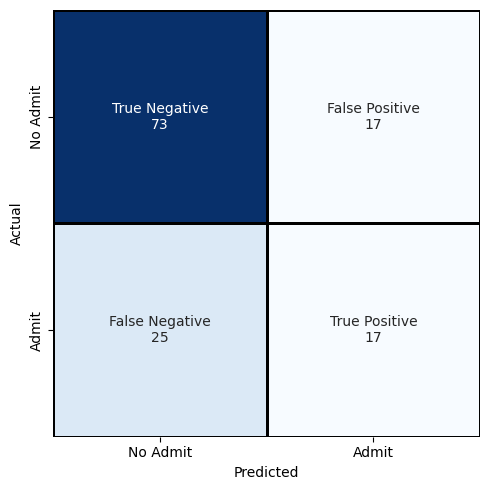

In [12]:
labels_text = np.array([
    ['True Negative', 'False Positive'],
    ['False Negative', 'True Positive']
])
 
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f'{labels_text[i, j]}\n{cm[i, j]}'
 
fig, ax = plt.subplots(figsize=(6, 5))
 
sns.heatmap(
    cm,
    annot=annot,
    fmt='',
    cmap='Blues',
    cbar=False,
    square=True,
    linewidths=1,
    linecolor='black',
    ax=ax
)
 
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticklabels(['No Admit', 'Admit'])
ax.set_yticklabels(['No Admit', 'Admit'])
#ax.set_xticklabels(['0', '1'])
#ax.set_yticklabels(['0', '1'])
 
plt.tight_layout()
plt.show()

In [13]:
accuracy  = accuracy_score(y_test, predictions) # oficial r2 for logistic regression
precision = precision_score(y_test, predictions)
recall    = recall_score(y_test, predictions)
f1        = f1_score(y_test, predictions)
auc       = roc_auc_score(y_test, probs)
 
accuracy, precision, recall, f1, auc

(0.6818181818181818,
 0.5,
 0.40476190476190477,
 0.4473684210526316,
 0.6555555555555556)

**Accuracy**  
Proportion of all predictions that are correct.
 
**Precision**  
Proportion of predicted positives that are actually positive.
 
**Recall**  
Proportion of actual positives that the model successfully identifies.
 
**F1 Score**  
Harmonic mean of precision and recall, balancing both in a single metric.
 
**AUC (Area Under the ROC Curve)**  
Probability that the model ranks a randomly chosen positive example higher than a randomly chosen negative one.

In [14]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.81      0.78        90
           1       0.50      0.40      0.45        42

    accuracy                           0.68       132
   macro avg       0.62      0.61      0.61       132
weighted avg       0.67      0.68      0.67       132



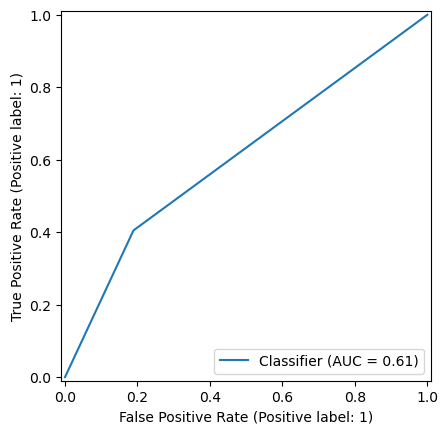

In [15]:
RocCurveDisplay.from_predictions(y_true, y_pred);